# Approximate GP in data-centric fashion using SVGP


In [1]:
# restart kernel
from IPython.core.display import HTML
HTML("<script>Jupyter.notebook.kernel.restart()</script>")

import math, random, pickle, os, copy, itertools, sys, gpytorch
import torch, logging, scipy.io # , tqdm
import numpy as np
import pandas as pd
import seaborn as sns
from numpy import random
from datetime import datetime

import matplotlib.pyplot as plt
from collections.abc import Iterable
%matplotlib inline

BASE_DIR = os.path.dirname(os.path.dirname(os.getcwd()))
sys.path.insert(1, BASE_DIR)

import config
config.init()
from config import device
from server.util import WrapLogger
from server.abstract import _calib_error
from server.pooled_server import PooledGPModel
from utils.analyze_results import *
from utils.assistive_functions import load_trained_models, softplus_inverse, normalize_data_tup
from utils.train_models import train_models

random_seed = 25
random.seed(random_seed)
np.random.seed(random_seed)
torch.manual_seed(random_seed)
random_state = np.random.RandomState(random_seed)

if torch.cuda.is_available() and not str(device)=='cpu':
    print('[INFO] running on GPU core ' + str(torch.cuda.current_device()))
else:
    print('[WARN] running on CPU')
#import platform
#platform.platform()

[INFO] running on GPU core 2


In [2]:
from matplotlib import pyplot as plt
from scipy.io import loadmat
from math import floor

# Make plots inline
%matplotlib inline

# Load data


In [12]:
exp_name = 'PV_BiModal'         # PV_BiModal, PV_UniModal_augmented', PV_UniModal
scenario_name_fl = '1y'
run_only_best = True
normalization = 'mean_std' # 'min_max' #'mean_std'
# save_maml = True

elev_data = False

if elev_data:
    data = torch.Tensor(loadmat(os.path.join(os.getcwd(), 'elevators.mat'))['data'])
    X = data[:, :-1]
    X = X - X.min(0)[0]
    X = 2 * (X / X.max(0)[0]) - 1
    y = data[:, -1]
    train_n = int(floor(0.8 * len(X)))
    train_x = X[:train_n, :].contiguous()
    train_y = y[:train_n].contiguous()

    test_x = X[train_n:, :].contiguous()
    test_y = y[train_n:].contiguous()

else:
    # ------ LOAD DATA ------
    filename_env = config.PVDATA_DIR + '/'+ exp_name+"_env"
    file = open(filename_env, 'rb')
    env_dict = pickle.load(file)
    msg = '[INFO] loaded data for {:2.0f} clients'.format(env_dict['num_clients'])
    print(msg)
    file.close()
    num_clients = env_dict['num_clients'] 

    clients_data = env_dict['train_scenarios'][scenario_name_fl]['clients_data']
    num_samples = clients_data[0][0].shape[0]
    num_samples_test = clients_data[0][2].shape[0]
    num_features = len(env_dict['feature_names'])
    # augment data
    train_x = np.zeros((num_samples*num_clients, num_features))
    train_y = np.zeros((num_samples*num_clients))
    test_x = np.zeros((num_samples_test*num_clients, num_features))
    test_y = np.zeros((num_samples_test*num_clients))
    for client_num in np.arange(num_clients):
        train_x[num_samples*client_num:num_samples*(client_num+1), :] = clients_data[client_num][0]
        train_y[num_samples*client_num:num_samples*(client_num+1)] = clients_data[client_num][1].flatten()
        test_x[num_samples_test*client_num:num_samples_test*(client_num+1), :] = clients_data[client_num][2]
        test_y[num_samples_test*client_num:num_samples_test*(client_num+1)] = clients_data[client_num][3].flatten()
    # normalize
    if normalization == 'min_max':
        x_min = train_x.min(0)[0]
        x_max = train_x.max(0)[0]
        train_x = 2 * ((train_x-x_min) / (x_max-x_min)) - 1
        test_x = 2 * ((test_x-x_min) / (x_max-x_min)) - 1
    else:
        train_y, test_y = train_y.reshape(-1,1), test_y.reshape(-1,1)
        # statistics on train data
        x_mean, y_mean = np.mean(train_x, axis=0), np.mean(train_y, axis=0)
        x_std, y_std = np.std(train_x, axis=0) + 1e-8, np.std(train_y, axis=0) + 1e-8
        # normalize
        train_x = (train_x - x_mean[None, :]) / x_std[None, :]
        train_y = ((train_y - y_mean[None, :]) / y_std[None, :]).flatten()
        test_x = (test_x - x_mean[None, :]) / x_std[None, :]
        test_y = ((test_y - y_mean[None, :]) / y_std[None, :]).flatten()
    # to tensor
    train_x = torch.from_numpy(train_x).to(device).float()    
    train_y = torch.from_numpy(train_y).to(device).float()  
    test_x = torch.from_numpy(test_x).to(device).float()  
    test_y = torch.from_numpy(test_y).to(device).float()  

# print(train_x.dtype)
# print(train_x.shape, train_y.shape, test_x.shape, test_y.shape)
    

[INFO] loaded data for 24 clients
torch.float32
torch.Size([3600, 15]) torch.Size([3600, 1]) torch.Size([14640, 15]) torch.Size([14640, 1])


In [4]:
from torch.utils.data import TensorDataset, DataLoader
train_dataset = TensorDataset(train_x, train_y)
train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True)

test_dataset = TensorDataset(test_x, test_y)
test_loader = DataLoader(test_dataset, batch_size=1024, shuffle=False)
train_loader_val = DataLoader(train_dataset, batch_size=1024, shuffle=False)


# ----- SET UP LOGGER -----
now = datetime.now().strftime("%m_%d")
file_name_base = os.path.join(BASE_DIR, 'experiments', 'PV', 'saved_results', exp_name)

filename_log  = os.path.join(file_name_base, 'pooled', 'best' if run_only_best else 'all' + '_models_' + scenario_name_fl) + "_log" + now
filename_save = os.path.join(file_name_base, 'pooled', 'best' if run_only_best else 'all' + '_models_' + scenario_name_fl) + "_models" + now

logging.basicConfig(filename=filename_log, format='%(asctime)s %(message)s', filemode='w')
logger=logging.getLogger('pooled')
logger.setLevel(logging.DEBUG)
logger = WrapLogger(logger)


In [5]:
layers = [(int(n),)*2 for n in np.logspace(1, 3, num=3, base=4)] + [(int(n),)*4 for n in np.logspace(1, 3, num=1, base=4)]
layer_pairs = list(itertools.product(layers, layers))
methods = []
for layer_pair in layer_pairs:
    mean_layers = layer_pair[0]
    kernel_layers = layer_pair[1]
    methods.append(
        'nn'+str(mean_layers[0])+'x'+str(len(mean_layers)) \
        + '_' + 
        'nn'+str(kernel_layers[0])+'x'+str(len(kernel_layers))
    )

results_pooled = dict.fromkeys(methods)
models_pooled = dict.fromkeys(methods)
for met in methods:
    results_pooled[met] = {
        'sml':{
            'rsmse':{'criterion_train':None, 'criterion_valid':None}, 
            'calibr':{'criterion_train':None, 'criterion_valid':None}
        },
        '1y':{
            'rsmse':{'criterion_train':None, 'criterion_valid':None}, 
            'calibr':{'criterion_train':None, 'criterion_valid':None}
        }
    }
    models_pooled[met] = {
        'sml':None, '1y':None
    }


In [10]:
num_epochs = 1500
num_inducing_points = 500
best_models = {
    'PV_UniModal':{
        'sml':{'met':['nn4x2_nn4x4'], 'lay':[((4,4), (4,4,4,4))]},
        '1y':{'met':['nn4x2_nn4x2'], 'lay':[((4,4), (4,4))]}
    },
    'PV_BiModal':{
        'sml':{'met':['nn4x2_nn64x2'], 'lay':[((4,4), (64,64))]},
        '1y':{'met':['nn4x2_nn4x2'], 'lay':[((4,4), (4,4))]}
    }
}
if run_only_best:
    methods_to_run = best_models[exp_name][scenario_name_fl]['met'] 
    layer_pairs_to_run = best_models[exp_name][scenario_name_fl]['lay'] 
else:  
    methods_to_run = methods 
    layer_pairs_to_run = layer_pairs


for method, layer_pair in zip(methods_to_run, layer_pairs_to_run):
    logger.info('\n'+ method)
    # ---- 1. initialize the model ----
    inducing_points = train_x[random_state.choice(
            np.arange(train_x.shape[0]), size=num_inducing_points, replace=False
    ), :]
    model = PooledGPModel(
        inducing_points=inducing_points, 
        mean_module_str='NN', covar_module_str='NN', 
        mean_nn_layers=layer_pair[0], kernel_nn_layers=layer_pair[1], 
        feature_dim=2
    ).to(device)
    likelihood = gpytorch.likelihoods.GaussianLikelihood().to(device)
    #print('before ', model.nn_kernel_map.fc_1.weight)
    # ---- 2. train the model ----
    model.train()
    likelihood.train()
    params_to_opt = model.shared_parameters + [
        {'params': likelihood.parameters()},
    ]
    optimizer = torch.optim.Adam(params_to_opt, lr=0.01)
    mll = gpytorch.mlls.VariationalELBO(likelihood, model, num_data=train_y.size(0))
    for epoch_num in np.arange(num_epochs):
        for x_batch, y_batch in train_loader:
            optimizer.zero_grad()
            output = model(x_batch)
            loss = -mll(output, y_batch)
            loss.backward()
            optimizer.step()
            if epoch_num%200==0:
                logger.info('iter {:5.0f} - loss {:2.4f}'.format(epoch_num, loss.item()))
    # ---- 3. predict and eval ----
    for train_or_valid in ['train', 'valid']:
        model.eval()
        likelihood.eval()
        # ---- 3.a predict ----
        means = torch.tensor([0.]).to(device)
        stddevs = torch.tensor([0.]).to(device)
        with torch.no_grad():
            loader = train_loader_val if train_or_valid=='train' else test_loader
            for x_batch, y_batch in loader:
                preds = model(x_batch)
                means = torch.cat([means, preds.mean]) # .cpu()
                stddevs = torch.cat([stddevs, preds.stddev]) # .cpu()
        means = means[1:]
        stddevs = stddevs[1:]
        # print(means.shape, stddevs.shape)
        # ---- 3.b RSMSE ----
        rsmse_all = torch.zeros(num_clients)
        ce_all = torch.zeros(num_clients)
        n_st = 0
        for client_num in np.arange(num_clients):
            n_en = n_st+clients_data[client_num][0].shape[0] if train_or_valid=='train' else n_st+clients_data[client_num][2].shape[0]
            inds = np.arange(n_st, n_en)
            test_y_cl = train_y[inds] if train_or_valid=='train' else test_y[inds]
            n_st = n_en
            # RSMSE
            rsmse_all[client_num] = torch.sqrt(torch.mean(
                (means[inds] - test_y_cl)**2))/torch.std(test_y_cl)
            # calibr
            pred_dist_vect = torch.distributions.Normal(means[inds], stddevs[inds])
            ce_all[client_num] = _calib_error(pred_dist_vect, test_y_cl)
            
        assert n_en == len(means)
        results_pooled[method][scenario_name_fl]['rsmse']['criterion_'+train_or_valid] = rsmse_all
        results_pooled[method][scenario_name_fl]['rsmse']['criterion_'+train_or_valid] = ce_all
        logger.info('\n---- results with random seed  = {:2.0f} ----'.format(random_seed))
        logger.info('RSMSE ' + train_or_valid+ ' = {:1.6f}'.format(torch.mean(rsmse_all)))
        logger.info('CE ' + train_or_valid+ ' = {:1.6f}'.format(torch.mean(ce_all)))
    
        
    # ---- 4. compress and save model ----
    #params_to_opt



nn4x2_nn64x2
iter     0 - loss 2.0865
iter     0 - loss 2.0312
iter     0 - loss 1.9025
iter     0 - loss 1.8824
iter   200 - loss 0.2245
iter   200 - loss 0.1382
iter   200 - loss 0.1259
iter   200 - loss 0.1089
iter   400 - loss 0.1629
iter   400 - loss 0.0604
iter   400 - loss 0.0767
iter   400 - loss 0.0957
iter   600 - loss 0.1121
iter   600 - loss 0.1260
iter   600 - loss 0.0360
iter   600 - loss 0.0236
iter   800 - loss 0.1305
iter   800 - loss 0.0367
iter   800 - loss 0.0704
iter   800 - loss 0.1045
iter  1000 - loss 0.0448
iter  1000 - loss 0.1177
iter  1000 - loss 0.0422
iter  1000 - loss 0.0968
iter  1200 - loss 0.0476
iter  1200 - loss 0.0977
iter  1200 - loss 0.0937
iter  1200 - loss 0.0013
iter  1400 - loss 0.0415
iter  1400 - loss 0.0543
iter  1400 - loss 0.0818
iter  1400 - loss 0.1088
RSMSE train = 0.334609
CE train = 0.260854
RSMSE valid = 0.452414
CE valid = 0.258822


# New Clients
Different from all other methods, the training dataset of the enew clients has no effect in the model for them. This is because the pooled GP model does not allow adaptation to clients data.

In [11]:
exp_name_ptc = exp_name
exp_name_new = exp_name_ptc + '_NewClients'

# ----- SET UP LOGGER -----
filename_env_new = config.PVDATA_DIR + '/'+ exp_name_ptc +"_new_clients_env"
filename_res_new = os.path.join(os.getcwd(), "saved_results", exp_name_new)


# ------ LOAD META_TEST DATA ------
file = open(filename_env_new, 'rb')
env_dict_new = pickle.load(file)
msg = '[INFO] loaded data for {:2.0f} clients'.format(env_dict_new['num_clients'])
print(msg)
file.close()
num_clients_new = env_dict_new['num_clients'] 
print('\n'+env_dict_new['info'])

clients_data_new = env_dict_new['train_scenarios']['sml']['clients_data']



[INFO] loaded data for 24 clients

24 households at Lausanne Lausanne - tilt_std: 5.0, az_std: 15.0, weather_dev: 0.1, irrad_std: 0.2, altitude_dev: 0.1, shadow_peak_red: 0.8, different module_name, different inverter_name, 


In [22]:
model.eval()
likelihood.eval()
rsmse_new = torch.zeros(num_clients_new)
ce_new = torch.zeros(num_clients_new)
pred_means = [None]*num_clients_new
pred_stds = [None]*num_clients_new

for client_num_new in np.arange(num_clients_new):
    train_x, train_y, test_x, test_y = clients_data_new[client_num_new]
    # normalize
    if normalization == 'min_max':
        train_x = 2 * ((train_x-x_min) / (x_max-x_min)) - 1
        test_x  = 2 * ((test_x-x_min) / (x_max-x_min)) - 1
    else:
        train_x = (train_x - x_mean[None, :]) / x_std[None, :]
        train_y = (train_y - y_mean[None, :]) / y_std[None, :].flatten()
        test_x = (test_x - x_mean[None, :]) / x_std[None, :]
        test_y = (test_y - y_mean[None, :]) / y_std[None, :].flatten()
    # to tensor
    train_x = torch.from_numpy(train_x).to(device).float()    
    train_y = torch.from_numpy(train_y).to(device).float()  
    test_x = torch.from_numpy(test_x).to(device).float()  
    test_y = torch.from_numpy(test_y).to(device).float()  
    # predict on the validation set
    with torch.no_grad():
        preds = model(test_x)
        # RSMSE
        rsmse_new[client_num_new] = torch.sqrt(torch.mean(
            (preds.mean.flatten() - test_y.flatten())**2))/torch.std(test_y)
        # calibr
        pred_dist_vect = torch.distributions.Normal(preds.mean.flatten(), preds.stddev.flatten())
        ce_new[client_num_new] = _calib_error(pred_dist_vect, test_y.flatten())
        pred_means[client_num_new] = preds.mean.detach().cpu().numpy()
        pred_stds[client_num_new] = preds.stddev.detach().cpu().numpy()

logger.info('RSMSE new = {:1.6f}'.format(torch.mean(rsmse_new)))
logger.info('CE new = {:1.6f}'.format(torch.mean(ce_new)))
    

RSMSE new = 0.454592
CE new = 0.261373


(140,) (140,) (140,)
(140,) (140,) (140,)


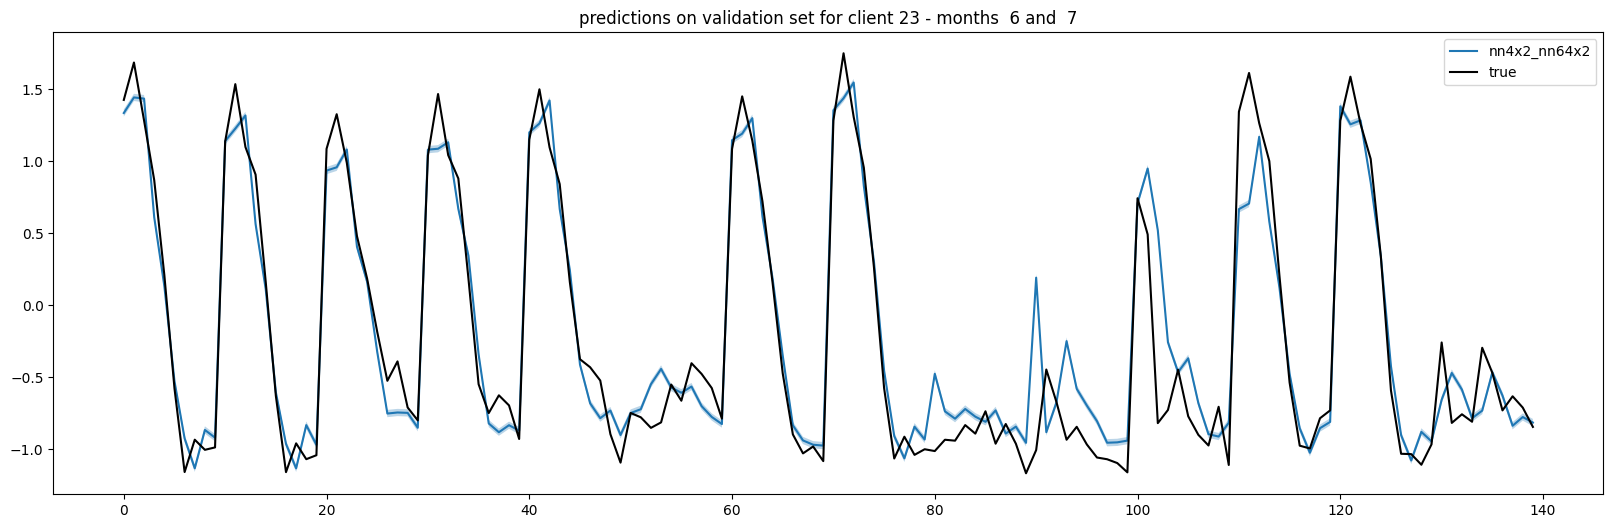

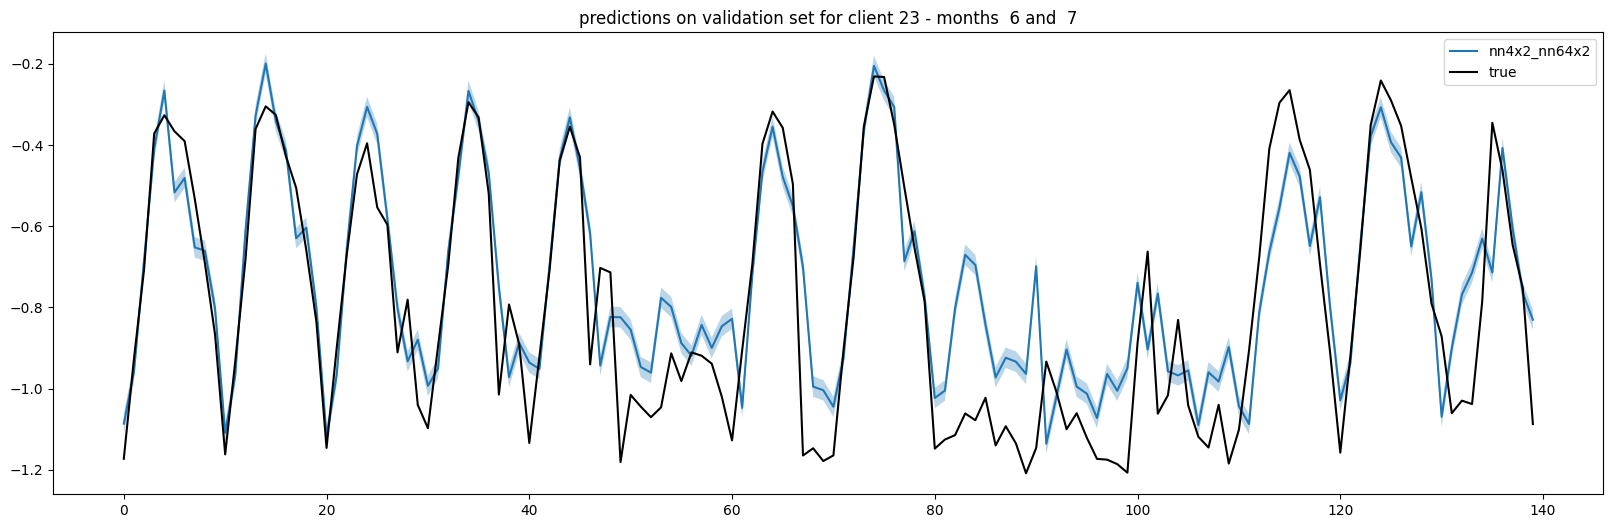

In [31]:
run_cell = False
if run_cell:
    for client_num_plt in [0, 23]:
        num_days = 14
        inds = np.arange(10*num_days)

        pred_mean, pred_std = pred_means[client_num_plt][inds], pred_stds[client_num_plt][inds]
        fig, ax = plt.subplots(1,1, figsize=(20,6))
        ax.plot(inds, pred_mean, label=method)
        print(inds.shape, pred_mean.shape, pred_std.shape)
        ax.fill_between(
            inds,
            pred_mean-1.96*pred_std,pred_mean+1.96*pred_std, alpha=0.3)

        ax.plot(
            inds, 
            ((clients_data_new[client_num_plt][3] - y_mean[None, :]) / y_std[None, :]).flatten()[inds], # normalized validation data
            'black', label='true')
        ax.set_title(
            'predictions on validation set for client {:2.0f} - months {:2.0f} and {:2.0f}'.format(
                client_num, env_dict['months'][0], env_dict['months'][1]))
        ax.legend()

In [ ]:
# # RSMSE of predicting constant
# best_const = torch.mean(train_y).detach().cpu().numpy().flatten()[0]
# print(best_const)

# for train_or_test in ['train', 'test']:
#     rsmse_from_const = np.zeros(num_clients)
#     n_st = 0
#     for client_num in np.arange(num_clients):
#         n_en = n_st+clients_data[client_num][0].shape[0] if train_or_test=='train' else n_st+clients_data[client_num][2].shape[0]
#         inds = np.arange(n_st, n_en)
#         test_y_cl = train_y.cpu()[inds] if train_or_test=='train' else test_y.cpu()[inds]
#         rsmse_from_const[client_num] = torch.sqrt(torch.mean(
#             (best_const - test_y_cl)**2))/torch.std(test_y_cl)
#         n_st = n_en
#     print(train_or_test + ' RSMSE fron best constant mean: ', np.mean(rsmse_from_const))

39.23066
train RSMSE fron best constant mean:  1.3020356893539429
test RSMSE fron best constant mean:  1.333646168311437


In [11]:
# ---- S-sml ----
# RSMSE - EXS: [0.516213, 0.464767, 0.475671, 0.479865, 0.481418]
# CE    - EXS: [0.257457, 0.252739, 0.258333, 0.257443, 0.254508]
# RSMSE - NEW: [0.505538, 0.463375, 0.469100, 0.471160, 0.473602]
# CE    - NEW: [0.260765, 0.263053, 0.263030, 0.261944, 0.263589]

# ---- EW-sml ----
# RSMSE - EXS: [0.452414, 0.457770, 0.452043, 0.460078, 0.511978]
# CE    - EXS: [0.258822, 0.260567, 0.256273, 0.270373, 0.256281]
# RSMSE - NEW: [0.454592, 0.459067, 0.453501, 0.462595, 0.515246]
# CE    - NEW: [0.261373, 0.262383, 0.257726, 0.272547, 0.260289]

# ---- S-1y ----
# RSMSE - EXS: [0.476086, 0.499914, 0.483939, 0.507822, 0.490060]
# CE    - EXS: [0.265943, 0.267027, 0.259745, 0.261892, 0.262458]
# RSMSE - NEW: [0.469572, 0.489554, 0.470984, 0.499135, 0.476360]
# CE    - NEW: [0.271329, 0.269022, 0.269345, 0.269658, 0.268024]

# ---- EW-1y ----
# RSMSE - EXS: [0.462601, 0.455600, 0.467739, 0.436948, 0.483411]
# CE    - EXS: [0.264020, 0.274700, 0.261667, 0.266810, 0.261069]
# RSMSE - NEW: [0.461903, 0.454146, 0.466830, 0.437337, 0.480296]
# CE    - NEW: [0.264117, 0.279747, 0.260449, 0.264389, 0.262288]
import numpy as np
print('{:1.3f}, {:1.3f}'.format(np.mean(a), 1.96*np.std(a)) )

0.266, 0.014
